In [1]:
# imports
import os
import sys
sys.path.append("../")
sys.path.append("../Modules/")
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np
# import generic morphology plotting function
from Modules import plot_morphology
from Modules import analysis
# import reading seg data function
# there isn't one? we just read the csv file using pandas.


real seg data

In [2]:
# sim_directory = '/home/drfrbc/Neural-Modeling/scripts/2024-12-23-15-23-44-BenSynapses_final_detailed_syn_dist_analysis/Complex_InhGmaxApic7.1_InhGmaxDend0.0016_SomaGmax0.0025_ExcGmax-1.0351_Np1000'
sim_directory = "/home/drfrbc/Neural-Modeling/cells/segment_info/L5PC_medium_seg_res"

In [3]:
# read seg data
seg_data = pd.read_csv(os.path.join(sim_directory, "segment_data.csv"))

# # read synapses
# syn_data = read_synapse_distribution_file(sim_directory)
# # read transfer impedances
# imp_df = read_transfer_impedance_file(sim_directory, loc='soma')
# seg_data['soma_trans_imp'] = imp_df.beta_active

In [4]:
for i,seg in seg_data.iterrows():
    print(seg.seg)
    if i == 0:
        break

L5PCtemplate[0].soma[0](0.5)


example data (to be replaced later)

In [5]:
# example data (to be replaced later)
location_types_by_synapse_type = {
    'inhPerisomatic': ['perisomatic'],
    'exc': ['distal_basal', 'distal_apic'],
    'inhDendritic': ['distal_basal', 'distal_apic']
}

segments = [seg.seg for i,seg in seg_data.iterrows()]#[seg for sec in synapses['exc'].cell.all for seg in sec]
results = []
resulting_PSCs_by_segment = {}
for synapse_type in location_types_by_synapse_type.keys():
  resulting_PSCs_by_segment[synapse_type] = {} # make 1 for each tuner/synapse type
  resulting_PSCs_by_segment[synapse_type]['segments'] = segments#[seg for sec in synapses[synapse_type].cell.all for seg in sec] # list segments for each tuner Segments are the same, but identified differently bc each tuner built its own cell.
  for location_type in location_types_by_synapse_type[synapse_type]: # make one for each location type
    resulting_PSCs_by_segment[synapse_type][location_type] = [[0] for seg in resulting_PSCs_by_segment[synapse_type]['segments']] # initialize list of PSCs that were used for each segment
    for i, seg in enumerate(resulting_PSCs_by_segment[synapse_type]['segments']):
      if resulting_PSCs_by_segment[synapse_type][location_type][i] == []: # if there are no PSCs for this segment, initialize it to 0
        resulting_PSCs_by_segment[synapse_type][location_type][i] = [0]

In [6]:
# Load real data from a file
import pickle
with open('/home/drfrbc/Neural-Modeling/notebooks/no_std_PSCs_by_segment.pkl', 'rb') as f:
    resulting_PSCs_by_segment = pickle.load(f)

In [7]:
# replace untested segments with 0.
for synapse_type, locations in resulting_PSCs_by_segment.items():
    for location, PSCs_by_segment in locations.items():
        for seg_id, seg_PSCs in enumerate(PSCs_by_segment):
            if seg_PSCs == []:
                    resulting_PSCs_by_segment[synapse_type][location][seg_id] = [0]
                    # print(f"{synapse_type} {location} {seg_PSCs} {resulting_PSCs_by_segment[synapse_type][location][seg_id]}")

In [8]:
for synapse_type, synapse_type_PSCs in resulting_PSCs_by_segment.items():
    segments = synapse_type_PSCs['segments']
    for location_type, PSCs in synapse_type_PSCs.items():
        if location_type != 'segments':
            print(f"{len(resulting_PSCs_by_segment[synapse_type][location_type])} {len(segments)}")

# fix the saved data, ensure the segments align.
# Remove the outer square brackets
s = resulting_PSCs_by_segment['inhPerisomatic']['segments'].strip('[]')

# Split the string on commas and remove extra whitespace from each item
items = [item.strip() for item in s.split(',')]

print(items[640])
print(seg_data.seg[640])

643 21597
643 21597
643 21597
643 21597
643 21597
L5PCtemplate[1].axon[0](0.166667)
L5PCtemplate[0].axon[0](0.166667)


In [9]:
def plot_PSCs_on_morphology(resulting_PSCs_by_segment, seg_data, synapse_type_to_plot, data_to_plot_name, clim_max=30):
    location_types = []
    synapse_types = []
    titles = []
    for synapse_type in location_types_by_synapse_type.keys():
        if synapse_type_to_plot in synapse_type:
            for location_type in location_types_by_synapse_type[synapse_type]:
                location_types.append(location_type)
                synapse_types.append(synapse_type)
                titles.append(f'{synapse_type} {location_type}')
                if data_to_plot_name == 'PSC_mean':
                    data_to_plot = [np.mean(resulting_PSCs_by_segment[synapse_type][location_type][seg_id]) for seg_id in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))]
                elif data_to_plot_name == 'PSC_std':
                    data_to_plot = [np.std(resulting_PSCs_by_segment[synapse_type][location_type][seg_id]) for seg_id in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))]
                else:
                    raise NotImplementedError(f'{data_to_plot_name}')

    fig, axes = plt.subplots(1, len(titles), figsize=(16, 8), subplot_kw={'projection': '3d'})
    # Ensure axes is always a list
    if len(titles) == 1:
        axes = [axes]

    for ax, synapse_type, location_type, title in zip(axes, synapse_types, location_types, titles):
        plot_morphology.plot(seg_data, data_to_plot, ax, title=title)
        # plot(seg_data, seg_id_column, variable_dict, ax, elevation=20, azimuth=-100, radius_scale=1.0, title='', clim_max=30)

    # Fix colorbar for global scaling
    # norm = plt.Normalize(vmin=0, vmax=clim_max)
    # mappable = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
    # plt.colorbar(mappable, ax=axes, shrink=0.6, label=data_to_plot_name, pad =-0.25)
    plt.tight_layout()
    plt.show()

In [10]:
# def plot_PSC_mean_std_on_morphology(resulting_PSCs_by_segment, seg_data, synapse_type_to_plot, data_to_plot_name, clim_max=30):
#     location_types = []
#     synapse_types = []
#     titles = []
#     datas_to_plot = []
#     for synapse_type in location_types_by_synapse_type.keys():
#         if synapse_type_to_plot in synapse_type:
#             for location_type in location_types_by_synapse_type[synapse_type]:
#                 for data_to_plot_name in ['PSC_mean', 'PSC_std']:
#                     location_types.append(location_type)
#                     synapse_types.append(synapse_type)
#                     titles.append(f'{synapse_type} {location_type} {data_to_plot_name}')
#                     if data_to_plot_name == 'PSC_mean':
#                         datas_to_plot.append([np.mean(resulting_PSCs_by_segment[synapse_type][location_type][seg_id]) for seg_id in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))])
#                     elif data_to_plot_name == 'PSC_std':
#                         datas_to_plot.append([np.std(resulting_PSCs_by_segment[synapse_type][location_type][seg_id]) for seg_id in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))])
#                     else:
#                         raise NotImplementedError(f'{data_to_plot_name}')
                    


#     fig, axes = plt.subplots(int(len(titles)/2), 2, figsize=(16, 8), subplot_kw={'projection': '3d'})
#     # Ensure axes is always a list
#     if len(titles) == 1:
#         axes = [axes]

#     for ax, synapse_type, location_type, title, data_to_plot in zip(axes, synapse_types, location_types, titles, datas_to_plot):
#         print(data_to_plot)
#         plot_morphology.plot(seg_data, data_to_plot, ax, title=title)

#         # Fix colorbar for global scaling
#         norm = plt.Normalize(vmin=0, vmax=clim_max)
#         mappable = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
#         plt.colorbar(mappable, ax=axes, shrink=0.6, label=data_to_plot_name, pad =-0.25)
#     plt.tight_layout()
#     plt.show()


def plot_PSC_mean_std_on_morphology(resulting_PSCs_by_segment, seg_data, synapse_type_to_plot,
                                    clim_max_mean=None, clim_max_std=None, percentile=95):
    import numpy as np
    import matplotlib.pyplot as plt

    location_types = []
    synapse_types = []
    titles = []
    datas_to_plot = []
    metrics = []
    
    # Build lists for subplots based on synapse and location types
    for synapse_type in location_types_by_synapse_type.keys():
        if synapse_type_to_plot in synapse_type:
            for location_type in location_types_by_synapse_type[synapse_type]:
                for metric in ['PSC_mean', 'PSC_std']:
                    location_types.append(location_type)
                    synapse_types.append(synapse_type)
                    titles.append(f'{synapse_type} {location_type} {metric}')
                    metrics.append(metric)
                    if metric == 'PSC_mean':
                        data = [
                            np.mean(resulting_PSCs_by_segment[synapse_type][location_type][i])
                            for i in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))
                        ]
                    elif metric == 'PSC_std':
                        data = [
                            np.std(resulting_PSCs_by_segment[synapse_type][location_type][i])
                            for i in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))
                        ]
                    datas_to_plot.append(data)
    
    # Compute robust clim_max values if not provided
    if clim_max_mean is None:
        mean_values = [val for m, data in zip(metrics, datas_to_plot) if m == 'PSC_mean' for val in data]
        clim_max_mean = np.percentile(mean_values, percentile) if mean_values else 1
        # clim_max_mean = max(mean_values) if mean_values else 1
    if clim_max_std is None:
        std_values = [val for m, data in zip(metrics, datas_to_plot) if m == 'PSC_std' for val in data]
        clim_max_std = np.percentile(std_values, percentile) if std_values else 1
        # clim_max_std = max(std_values) if std_values else 1

    print("Computed clim_max_mean:", clim_max_mean)
    print("Computed clim_max_std:", clim_max_std)
    
    # Set up subplots
    n_plots = len(titles)
    n_rows = int(np.ceil(n_plots / 2))
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 8), subplot_kw={'projection': '3d'})
    axes = np.atleast_1d(axes).flatten()
    
    # Plot each subplot, passing the appropriate clim_max to the plotting function
    for ax, title, metric, data in zip(axes, titles, metrics, datas_to_plot):
        clim = clim_max_mean if metric == 'PSC_mean' else clim_max_std
        # Here we simply pass clim_max to plot_morphology.plot
        cbar = plot_morphology.plot(seg_data, data, ax, title=title, clim_max=clim, return_cbar=True)
        cbar.set_label(metric)
    
    # Remove any extra axes if needed (for an odd number of plots)
    for ax in axes[n_plots:]:
        fig.delaxes(ax)
    
    plt.tight_layout()
    plt.show()


## inh perisomatic synapses

In [11]:
# data_to_plot_name = 'PSC_mean'
# synapse_type_to_plot = 'inhPerisomatic'
# clim_max=400
# plot_PSCs_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
#                         seg_data=seg_data,
#                         synapse_type_to_plot=synapse_type_to_plot,
#                         data_to_plot_name=data_to_plot_name,
#                         clim_max=clim_max)

In [12]:
# data_to_plot_name = 'PSC_std'
# synapse_type_to_plot = 'inhPerisomatic'
# clim_max=30
# plot_PSCs_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
#                         seg_data=seg_data,
#                         synapse_type_to_plot=synapse_type_to_plot,
#                         data_to_plot_name=data_to_plot_name,
#                         clim_max=clim_max)

Computed clim_max_mean: 600
Computed clim_max_std: 0.0


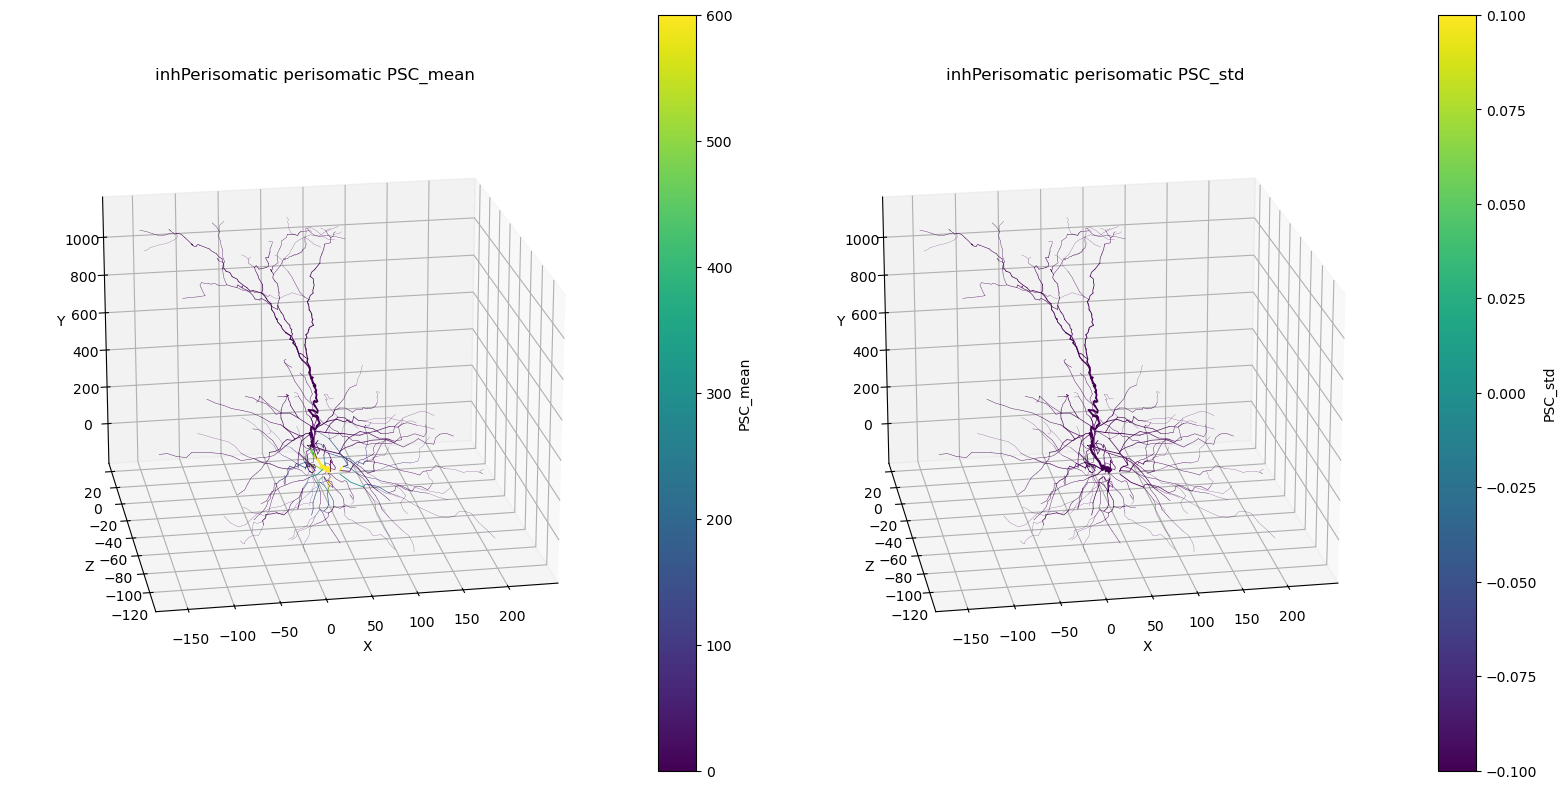

In [13]:
# testing plot psc mean and std together
data_to_plot_name = 'PSC_mean'
synapse_type_to_plot = 'inhPerisomatic'
# clim_max=500
plot_PSC_mean_std_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
                        seg_data=seg_data,
                        synapse_type_to_plot=synapse_type_to_plot, clim_max_mean = 600)

## inh distal synapses

Computed clim_max_mean: 39.88669979247261
Computed clim_max_std: 0.0


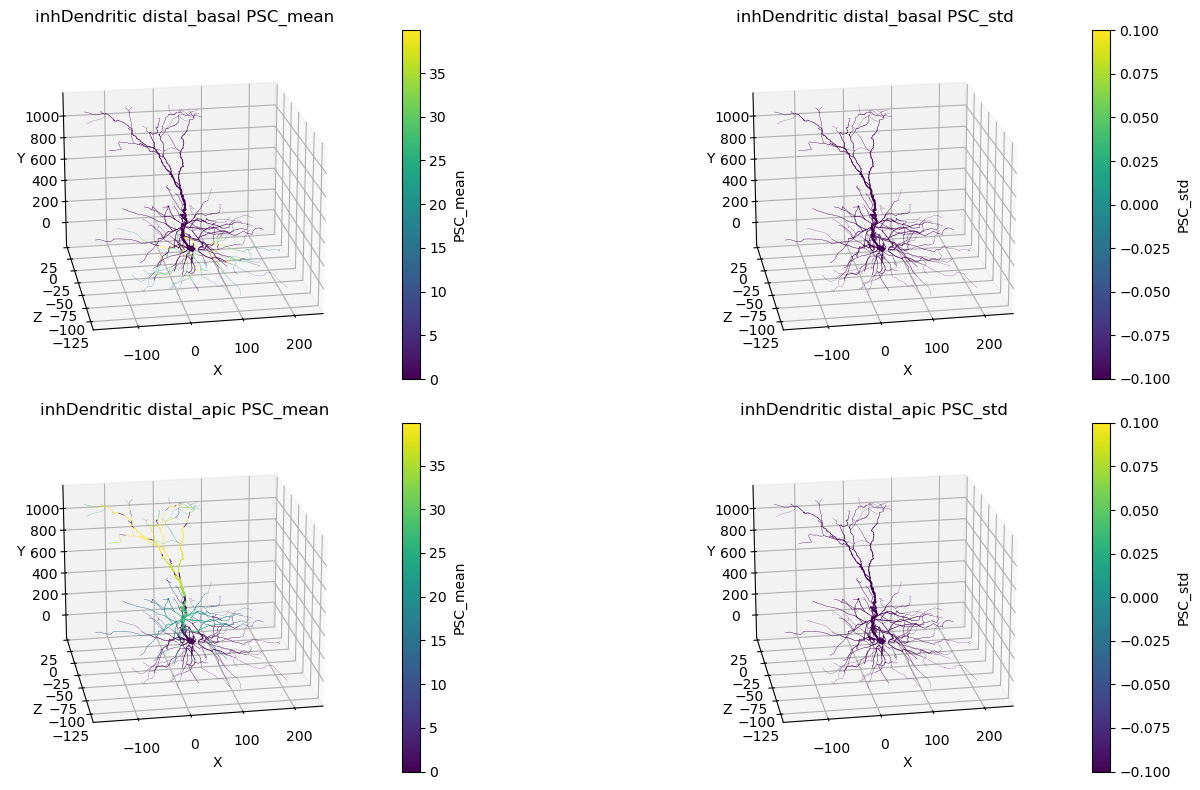

In [14]:
# data_to_plot_name = 'PSC_mean'
# synapse_type_to_plot = 'inhDendritic'
# clim_max=30
# plot_PSCs_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
#                         seg_data=seg_data,
#                         synapse_type_to_plot=synapse_type_to_plot,
#                         data_to_plot_name=data_to_plot_name,
#                         clim_max=clim_max)

# testing plot psc mean and std together
data_to_plot_name = 'PSC_mean'
synapse_type_to_plot = 'inhDendritic'
# clim_max=500
plot_PSC_mean_std_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
                        seg_data=seg_data,
                        synapse_type_to_plot=synapse_type_to_plot)

## exc distal synapses

Computed clim_max_mean: 40.54063785692675
Computed clim_max_std: 26.49709249427754


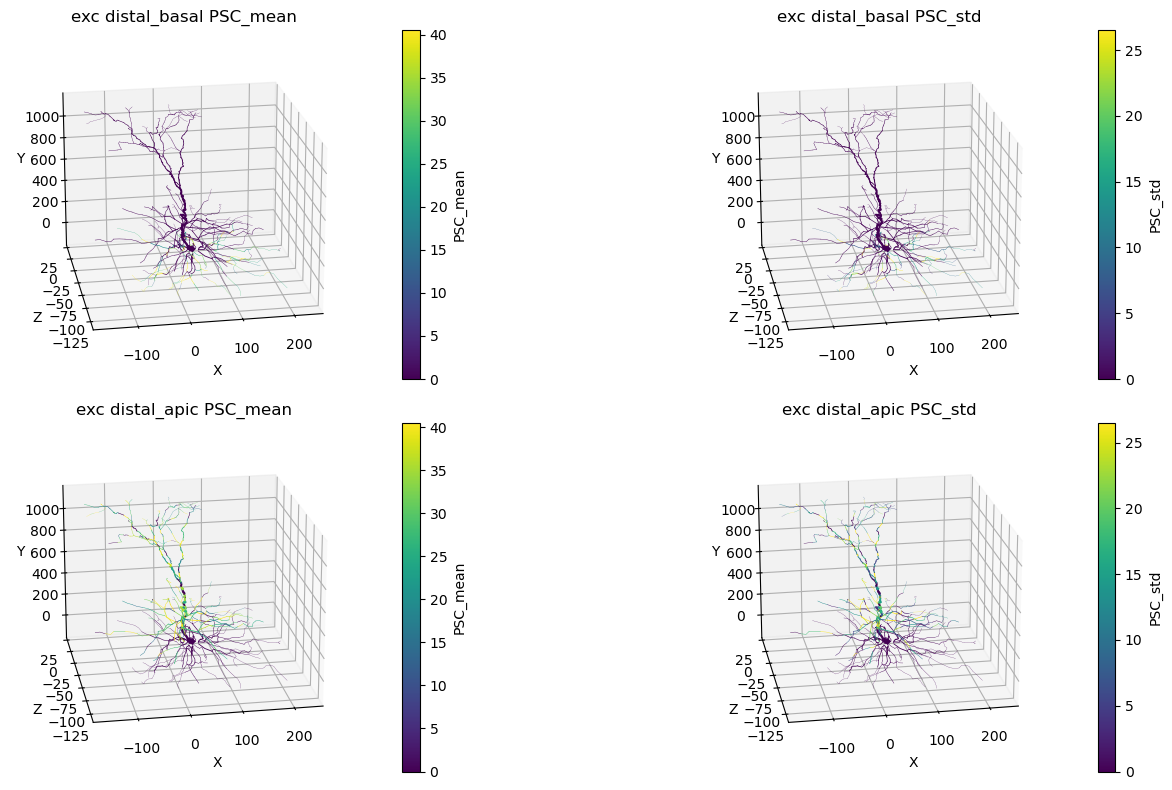

In [15]:
# data_to_plot_name = 'PSC_mean'
# synapse_type_to_plot = 'exc'
# clim_max=30
# plot_PSCs_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
#                         seg_data=seg_data,
#                         synapse_type_to_plot=synapse_type_to_plot,
#                         data_to_plot_name=data_to_plot_name,
#                         clim_max=clim_max)

data_to_plot_name = 'PSC_mean'
synapse_type_to_plot = 'exc'
# clim_max=500
plot_PSC_mean_std_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
                        seg_data=seg_data,
                        synapse_type_to_plot=synapse_type_to_plot)

In [16]:
# exc weights were not generated without STD it seems.